# E-Commerce Price Sensitivity Analysis

**Question:** How do customers respond to discounts? Where does extra discount buy extra volume, and where does it just give away margin?

**Data:** [E-Commerce Sales & Customer Analytics](https://www.kaggle.com/datasets/datascikhan/e-commerce-sales-and-customer-analytics) on Kaggle: about 138k orders and 398k order lines across 1,175 products, Jan 2021 to Dec 2025.

**Approach**
1. Work out where the price variation comes from (list price vs. discount).
2. Measure how units per order line change with the discount rate.
3. Turn that into price elasticity of demand.
4. Check whether the response differs by category or customer segment.
5. Put a value on it: revenue, profit and returns by discount band, then test alternative discount policies.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
if not (DATA_DIR / "order_items.csv").exists():
    from download_data import download
    download()

pd.set_option("display.float_format", "{:,.2f}".format)

# Chart styling: one blue for single series, orange as the second series, recessive grid/axes
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10, "figure.dpi": 110,
})

## 1. Load and join the data

In [2]:
items = pd.read_csv(DATA_DIR / "order_items.csv")
products = pd.read_csv(DATA_DIR / "product_catalog.csv")
orders = pd.read_csv(
    DATA_DIR / "ecommerce_sales_customer_analytics_150k.csv",
    usecols=["order_id", "order_date", "order_status", "customer_segment", "sales_channel"],
    parse_dates=["order_date"],
)

df = (
    items
    .merge(products[["product_id", "product_category", "unit_price"]]
           .rename(columns={"unit_price": "list_price"}), on="product_id")
    .merge(orders, on="order_id")
)
df["discount_pct"] = df["discount_percentage"] * 100
df["net_unit_price"] = df["unit_price"] * (1 - df["discount_percentage"])
# Merchandise revenue and profit per line, before tax and shipping
df["revenue"] = df["gross_sales"] - df["discount_amount"]
df["merch_profit"] = df["revenue"] - df["product_cost"]

print(f"{len(df):,} order lines | {df.order_id.nunique():,} orders | {df.product_id.nunique():,} products")
print(f"{df.order_date.min():%Y-%m-%d} to {df.order_date.max():%Y-%m-%d}")
df.head()

397,569 order lines | 138,116 orders | 1,175 products
2021-01-01 to 2025-12-31


,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,...,product_category,list_price,order_date,order_status,sales_channel,customer_segment,discount_pct,net_unit_price,revenue,merch_profit
0,ORD-301242,PROD-000738,2,244.40,0.34,166.00,488.80,22.60,6.48,351.88,...,Health & Wellness,244.40,2023-11-06,Completed,Mobile App,Consumer,33.96,161.40,322.80,149.52
1,ORD-301242,PROD-000181,3,287.13,0.36,311.89,861.39,38.47,5.55,593.52,...,Fashion,287.13,2023-11-06,Completed,Mobile App,Consumer,36.21,183.17,549.50,134.45
2,ORD-773460,PROD-000973,4,754.80,0.47,"1,413.89","3,019.20",305.01,9.00,"1,919.32",...,Jewelry,754.80,2025-12-24,Completed,Website,Premium,46.83,401.33,"1,605.31",-370.85
3,ORD-773460,PROD-000268,4,31.36,0.34,42.17,125.44,15.82,0.00,99.09,...,Beauty & Personal Care,31.36,2025-12-24,Completed,Website,Premium,33.62,20.82,83.27,27.55
4,ORD-449374,PROD-001040,3,6.31,0.09,1.70,18.93,1.21,0.98,19.42,...,Grocery,6.31,2021-07-05,Completed,Mobile App,Premium,8.97,5.74,17.23,11.32


## 2. Where does the price variation come from?

Price sensitivity can only be measured if prices vary. Below we check whether a product's list price ever changes, and how widely discounts vary.

In [3]:
list_price_changes = (df.groupby("product_id")["unit_price"].nunique() > 1).sum()
print(f"Products whose list price ever changes: {list_price_changes} of {df.product_id.nunique()}")
print(f"Lines sold at the catalog list price: {np.isclose(df.unit_price, df.list_price).mean():.0%}")
df["discount_pct"].describe(percentiles=[.1, .25, .5, .75, .9]).to_frame("discount %")

Products whose list price ever changes: 0 of 1175
Lines sold at the catalog list price: 100%


,discount %
count,"397,569.00"
mean,14.71
std,13.00
min,0.00
10%,0.00
25%,4.81
50%,12.43
75%,19.95
90%,33.32
max,60.00


**Finding:** each product's list price is fixed for the whole five years. **All price variation comes from discounts**, which range from 0% to 60% (median about 12%). So the question becomes *how does demand respond to the discount rate*, or equivalently to the net price paid.

## 3. Demand response to discount depth

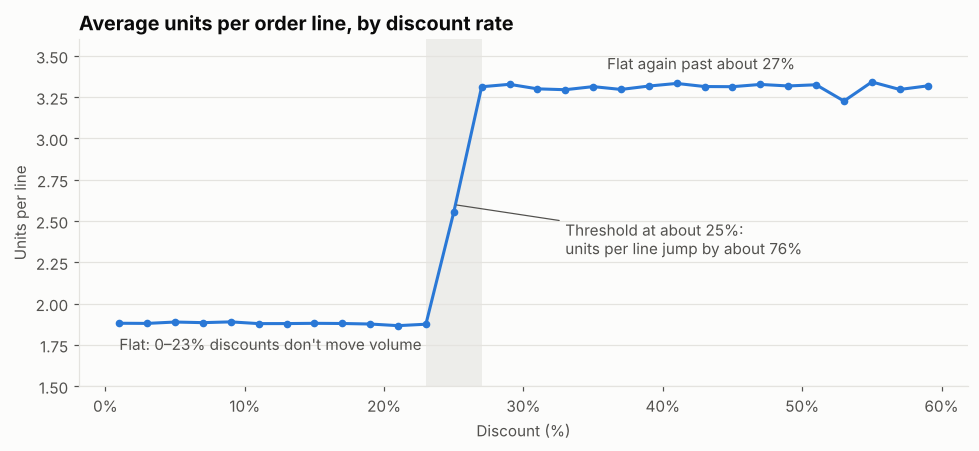

In [4]:
bins = np.arange(0, 62, 2)
by_disc = (
    df.assign(disc_bin=pd.cut(df.discount_pct, bins, right=False))
      .groupby("disc_bin", observed=True)
      .agg(units_per_line=("quantity", "mean"), lines=("quantity", "size"))
)
by_disc = by_disc[by_disc.lines >= 500]
x = [b.left + 1 for b in by_disc.index]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(x, by_disc.units_per_line, color=BLUE, lw=2, marker="o", ms=4)
ax.axvspan(23, 27, color=GRID, alpha=0.6, lw=0)
ax.annotate("Threshold at about 25%:\nunits per line jump by about 76%", xy=(25, 2.6), xytext=(33, 2.3),
            color=INK_2, arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.8))
ax.text(1, 1.72, "Flat: 0–23% discounts don't move volume", color=INK_2)
ax.text(36, 3.42, "Flat again past about 27%", color=INK_2)
ax.set(title="Average units per order line, by discount rate",
       xlabel="Discount (%)", ylabel="Units per line", ylim=(1.5, 3.6))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout(); plt.show()

**Finding:** demand doesn't fall smoothly as price drops. It's a **step function**:
- **0–23% off:** about 1.88 units per line, whatever the discount.
- **About 25% off:** volume jumps.
- **27%+ off:** a new plateau of about 3.3 units per line, with no extra lift from going deeper.

Customers behave as if they ignore anything below about 25% and respond only once a discount crosses that line.

## 4. Price elasticity of demand

Elasticity = % change in quantity ÷ % change in net price. Because the curve is a step, we report it in three parts instead of as one number.

In [5]:
bands = {"0–20%": (0, 20), "20–25%": (20, 25), "25–30%": (25, 30), "30–60%": (30, 61)}
rows = []
for name, (lo, hi) in bands.items():
    s = df[(df.discount_pct >= lo) & (df.discount_pct < hi)]
    rows.append({"band": name, "avg discount %": s.discount_pct.mean(),
                 "price paid (% of list)": 100 - s.discount_pct.mean(),
                 "units per line": s.quantity.mean(), "lines": len(s)})
elast = pd.DataFrame(rows).set_index("band")

def arc_elasticity(a, b):
    q0, q1 = elast.loc[a, "units per line"], elast.loc[b, "units per line"]
    p0, p1 = elast.loc[a, "price paid (% of list)"], elast.loc[b, "price paid (% of list)"]
    return ((q1 - q0) / ((q1 + q0) / 2)) / ((p1 - p0) / ((p1 + p0) / 2))

def within(lo, hi):
    s = df[(df.discount_pct >= lo) & (df.discount_pct < hi)]
    slope = np.polyfit(np.log(1 - s.discount_percentage), np.log(s.quantity), 1)[0]
    return slope

print(f"Within 0–20% off      (log-log slope): {within(0, 20):+.2f}")
print(f"Crossing the threshold (0–20% → 30–60%, arc): {arc_elasticity('0–20%', '30–60%'):+.2f}")
print(f"Within 30–60% off     (log-log slope): {within(30, 61):+.2f}")
elast

Within 0–20% off      (log-log slope): +0.01
Crossing the threshold (0–20% → 30–60%, arc): -1.24
Within 30–60% off     (log-log slope): -0.00


,avg discount %,price paid (% of list),units per line,lines
band,,,,
0–20%,8.71,91.29,1.88,298844
20–25%,22.49,77.51,1.87,32709
25–30%,27.16,72.84,3.32,17110
30–60%,41.76,58.24,3.31,48906


**Finding:**
- **Within 0–20% off, elasticity ≈ 0.** Volume doesn't react at all.
- **Across the threshold, arc elasticity is about −1.2** (elastic). Moving from the 0–20% band (about 9% off on average) to the 30–60% band (about 42% off) cuts the price paid by about 36% and lifts units by about 76%.
- **Within 30–60% off, elasticity ≈ 0 again.** Deeper discounts add nothing.

A single elasticity from one regression line would average these together and hide the pattern.

## 5. Is the response the same for every category and customer?

In [6]:
df["band"] = pd.cut(df.discount_pct, [-0.1, 20, 25, 30, 61], labels=["0–20%", "20–25%", "25–30%", "30–60%"])
cat = df.pivot_table(index="product_category", columns="band", values="quantity", aggfunc="mean", observed=True)
cat["lift past threshold"] = cat["30–60%"] / cat["0–20%"] - 1
seg = df.pivot_table(index="customer_segment", columns="band", values="quantity", aggfunc="mean", observed=True)
seg["lift past threshold"] = seg["30–60%"] / seg["0–20%"] - 1
display(cat.style.format("{:.2f}").format("{:+.0%}", subset=["lift past threshold"]))
display(seg.style.format("{:.2f}").format("{:+.0%}", subset=["lift past threshold"]))
print("Lift range across categories:", f"{cat['lift past threshold'].min():+.0%} to {cat['lift past threshold'].max():+.0%}")

band,0–20%,20–25%,25–30%,30–60%,lift past threshold
product_category,,,,,
Automotive,1.88,1.89,3.36,3.30,+76%
Baby & Kids,1.87,1.89,3.33,3.32,+77%
Beauty & Personal Care,1.89,1.91,3.29,3.30,+75%
Books & Media,1.90,1.84,3.31,3.32,+75%
Electronics,1.88,1.86,3.35,3.32,+76%
Fashion,1.89,1.90,3.29,3.35,+77%
Grocery,1.88,1.86,3.34,3.30,+76%
Health & Wellness,1.89,1.86,3.33,3.32,+76%
Home & Kitchen,1.88,1.87,3.34,3.30,+76%


band,0–20%,20–25%,25–30%,30–60%,lift past threshold
customer_segment,,,,,
Business,1.88,1.90,3.29,3.30,+75%
Consumer,1.88,1.87,3.31,3.31,+76%
Premium,1.88,1.87,3.33,3.31,+76%
VIP,1.88,1.88,3.34,3.31,+75%


Lift range across categories: +75% to +77%


**Finding:** the response is almost identical everywhere. All 15 categories and all 4 customer segments sit at about 1.88 units below the threshold and about 3.3 above it. Every year from 2021 to 2025 looks the same too.

> **Data caveat:** real customers would almost certainly react differently to discounts on groceries than on jewelry. A perfectly uniform step suggests the dataset is **synthetic** (generated by a rule). The method in this notebook carries over to real data, but the specific numbers describe this dataset, not real shoppers.

## 6. What does each discount level earn?

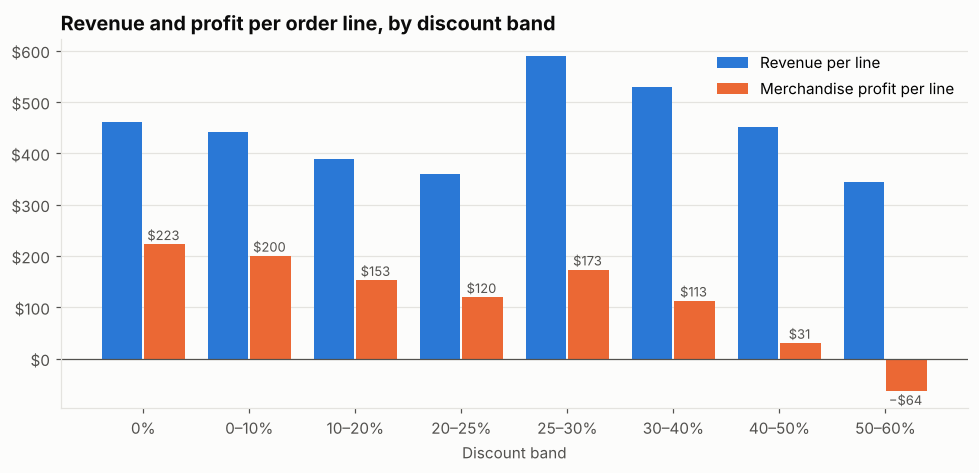

,units,revenue,merch_profit,lines
econ_band,,,,
0%,1.88,460.39,222.85,51567
0–10%,1.88,440.46,200.25,114949
10–20%,1.88,388.68,152.97,132328
20–25%,1.87,358.87,119.75,32709
25–30%,3.32,589.16,173.38,17110
30–40%,3.30,528.76,112.86,23230
40–50%,3.32,450.85,30.52,18241
50–60%,3.30,344.81,-64.22,7435


In [7]:
econ_bins = [-0.1, 0.01, 10, 20, 25, 30, 40, 50, 61]
labels = ["0%", "0–10%", "10–20%", "20–25%", "25–30%", "30–40%", "40–50%", "50–60%"]
econ = (
    df.assign(econ_band=pd.cut(df.discount_pct, econ_bins, labels=labels))
      .groupby("econ_band", observed=True)
      .agg(units=("quantity", "mean"), revenue=("revenue", "mean"), merch_profit=("merch_profit", "mean"),
           lines=("quantity", "size"))
)

fig, ax = plt.subplots(figsize=(9, 4.4))
xi = np.arange(len(econ))
w = 0.38
ax.bar(xi - w/2 - 0.01, econ.revenue, w, color=BLUE, label="Revenue per line")
ax.bar(xi + w/2 + 0.01, econ.merch_profit, w, color=ORANGE, label="Merchandise profit per line")
for i, v in enumerate(econ.merch_profit):
    ax.text(i + w/2, v + (8 if v >= 0 else -26), f"{'−' if v < 0 else ''}${abs(v):,.0f}", ha="center", color=INK_2, fontsize=8.5)
ax.axhline(0, color=INK_2, lw=0.8)
ax.set_xticks(xi, econ.index)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set(title="Revenue and profit per order line, by discount band", xlabel="Discount band")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout(); plt.show()
econ

**Finding:**
- **Profit per line is highest at 0% (about \$223).** Below the threshold every extra point of discount is pure margin loss, falling to about \$120 at 20–25% off. That band is the worst place to be: the deepest discounts that still buy no volume.
- **Revenue per line peaks in the 25–30% band (about \$589).** That's the best discount band on profit too (about \$173), but still about 22% below full price. The volume jump doesn't fully cover the margin given away.
- **Past 30%, revenue and profit both fall.** At 50–60% off the average line **loses about \$64**.

## 7. Discounts and returns

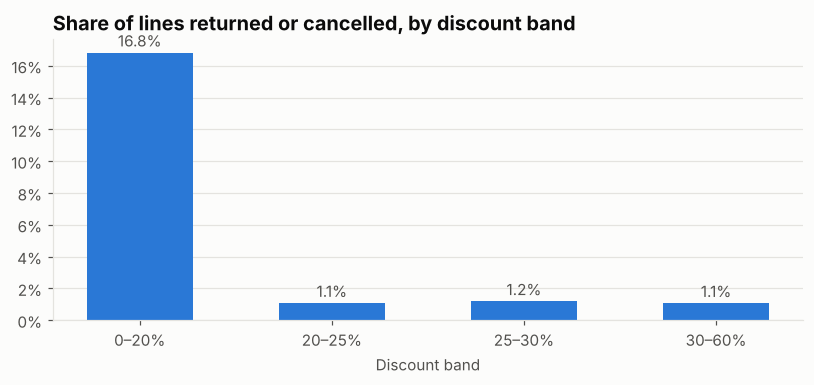

order_status,Cancelled,Completed,Pending,Returned
band,,,,
0–20%,0.08,0.79,0.05,0.09
20–25%,0.01,0.93,0.05,0.00
25–30%,0.01,0.93,0.06,0.01
30–60%,0.00,0.94,0.05,0.01


In [8]:
status = pd.crosstab(df.band, df.order_status, normalize="index")
fig, ax = plt.subplots(figsize=(7.5, 3.6))
rate = status["Returned"] + status["Cancelled"]
ax.bar(rate.index.astype(str), rate, color=BLUE, width=0.55)
for i, v in enumerate(rate):
    ax.text(i, v + 0.004, f"{v:.1%}", ha="center", color=INK_2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set(title="Share of lines returned or cancelled, by discount band", xlabel="Discount band")
plt.tight_layout(); plt.show()
status

**Finding:** lines with less than 20% off are returned or cancelled about **17%** of the time, against **about 1%** for lines with 20%+ off. Customers who get a bigger discount almost never go back on the purchase.

This is a correlation. It may say more about who buys at a big discount (people who already intended to buy) than about the discount itself.

## 8. Testing alternative discount policies

Using the demand curve from Section 3, we re-price the same order lines under three alternative policies and compare merchandise profit. Each line keeps its observed volume unless the new discount moves it across the threshold, in which case it takes the average units of its new side.

| Policy | Rule |
|---|---|
| **A. Drop small discounts** | Any discount under 23% → 0% |
| **B. Cap deep discounts** | Any discount over 30% → 30% |
| **C. Both** | A + B |

In [9]:
LOW_Q = df.loc[df.discount_pct < 23, "quantity"].mean()
HIGH_Q = df.loc[df.discount_pct >= 27, "quantity"].mean()

def simulate(new_disc_pct):
    new_disc_pct = new_disc_pct.astype(float)
    crosses_down = (df.discount_pct >= 27) & (new_disc_pct < 23)
    crosses_up = (df.discount_pct < 23) & (new_disc_pct >= 27)
    qty = df.quantity.astype(float).copy()
    qty[crosses_down] *= LOW_Q / HIGH_Q
    qty[crosses_up] *= HIGH_Q / LOW_Q
    unit_cost = df.product_cost / df.quantity
    revenue = qty * df.unit_price * (1 - new_disc_pct / 100)
    return pd.Series({"units": qty.sum(), "revenue": revenue.sum(), "merch_profit": (revenue - qty * unit_cost).sum()})

d = df.discount_pct
policies = {
    "Current": d,
    "A. Drop small discounts": d.where(d >= 23, 0),
    "B. Cap deep discounts at 30%": d.clip(upper=30),
    "C. Both": d.where(d >= 23, 0).clip(upper=30),
}
results = pd.DataFrame({name: simulate(p) for name, p in policies.items()}).T
base = results.loc["Current"]
for col in ["units", "revenue", "merch_profit"]:
    results[f"{col} vs current"] = results[col] / base[col] - 1
results.style.format({"units": "{:,.0f}", "revenue": "${:,.0f}", "merch_profit": "${:,.0f}",
                      "units vs current": "{:+.1%}", "revenue vs current": "{:+.1%}",
                      "merch_profit vs current": "{:+.1%}"})

,units,revenue,merch_profit,units vs current,revenue vs current,merch_profit vs current
Current,"842,366","$170,694,532","$64,336,855",+0.0%,+0.0%,+0.0%
A. Drop small discounts,"842,366","$184,624,647","$78,266,970",+0.0%,+8.2%,+21.7%
B. Cap deep discounts at 30%,"842,366","$175,338,848","$68,981,171",+0.0%,+2.7%,+7.2%
C. Both,"842,366","$189,268,964","$82,911,287",+0.0%,+10.9%,+28.9%


**Finding:**
- **Policy A (drop discounts under 23%): +22% merchandise profit, +8% revenue.** It removes discounts that bought no volume, so units don't change.
- **Policy B (cap at 30%): +7% profit, +3% revenue.** Volume holds because the plateau is flat past about 27%.
- **Combined (C): +29% profit (about \$18.6M over five years) with the same number of units sold.**

Policy A carries a risk the model can't price: these customers might simply be the ones who return orders less when they get a discount (Section 7). Run it as an A/B test before rolling it out.

## 9. Conclusions

1. **Price sensitivity here is a threshold, not a slope.** Discounts below about 23% have **zero measurable effect on volume**. Volume jumps about 76% once a discount reaches about 25–27%, and going deeper adds nothing.
2. **Elasticity depends on where you are on the curve.** It's about 0 within each plateau and about −1.2 across the threshold. A single elasticity estimate would mislead pricing decisions.
3. **The most profitable discount is no discount; the best promotional discount sits just past the threshold (about 25–30%).** Promotions should either clear the threshold or not run. Together, those two rules lift merchandise profit by about 29% with no loss of volume.
4. **Discounts past 30% destroy value.** Revenue and profit both fall, and 50%+ discounts lose money on the average line.
5. **The pattern is the same across every category, segment and year,** which strongly suggests synthetic data. On real data, run the same analysis by category to find each category's own threshold.

**Next steps on real data:** run controlled discount experiments around the threshold (20%, 25%, 30%). Model elasticity by category with product fixed effects. Track whether customers who get discounts keep coming back.